---
jupyter: python3
---


# Exercise 1: List patients using the get method from requests_fhir

The file request_fhir.py should be in the same folder as this markdown file.
From the exercise:

The request_fhir.py is a simple mock server which is built upon the data used throughout this course. This exercise is about trying to interact with data on a fhir database through restAPI calls where the usage of a base url is central. 

To understand the structure 

In [1]:
!pip install matplotlib-inline

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import request_fhir as requests
import pandas as pd
import matplotlib  
import matplotlib.pyplot as plt
import json


BASE_URL = 'https://test/fhir'
json_headers = {'content-type': 'application/json', 'accept': 'text/plain'}

Check if it works, the output should be related to error 501 (didn't actually ask for any information)

In [3]:
print(requests.get(BASE_URL))

<Response [501]>


Retrieving the full patient list:

In [4]:
BASE_URL = 'https://test/fhir/'
json_headers = {'Content-type': 'application/json',
'Accept': 'text/plain'}

patients_url = f'{BASE_URL}Patient'
response = requests.get(patients_url)

# The response content is correctly accessed via ._content
bundle = json.loads(response._content)
patients_df = pd.DataFrame(columns=['id', 'sex', 'd.birth'])

if bundle['resourceType'] == 'Bundle' and bundle['type'] == 'searchset':
    print(f"Found {len(bundle.get('entry', []))} patients:")
    for entry in bundle.get('entry', []):
        patient = entry.get('resource')
        if patient and patient['resourceType'] == 'Patient':
            patient_id = patient.get('id', 'N/A')
            sex = patient.get('gender', 'N/A')
            birthdate = patient.get('birthDate', 'N/A')
            
            new_row = pd.DataFrame([{'id': patient_id, 'sex': sex, 'd.birth': birthdate}])
            patients_df = pd.concat([patients_df, new_row], ignore_index=True)

print(patients_df)

Found 742 patients:
       id     sex     d.birth
0       2  female  1941-07-14
1       3    male  1931-10-02
2       4    male  1944-11-22
3       5  female  1939-04-13
4       6    male  1962-04-18
..    ...     ...         ...
737  1592  female  1942-04-06
738  1593    male  1950-02-08
739  1594  female  1928-12-07
740  1595    male  1942-08-27
741  1596  female  1936-04-05

[742 rows x 3 columns]


# Exercise 2: Look at the snomed.csv file inside the data folder to see which code to use to access the data

In [5]:
snomed_df = pd.read_csv('../../../exercise_data/raw_data/snomed.csv')
cholesterol_label = 'ldl'
cholesterol_info = snomed_df[snomed_df['label'] == cholesterol_label]
cholesterol_code = cholesterol_info['code'].iloc[0]
cholesterol_code

np.int64(166833005)

# Exercise 3: Get measurements of cholesterol for a patient

In [6]:
snomed = pd.read_csv("../../../exercise_data/raw_data/snomed.csv")

A plot for Patient 2's cholesterol has been generated.


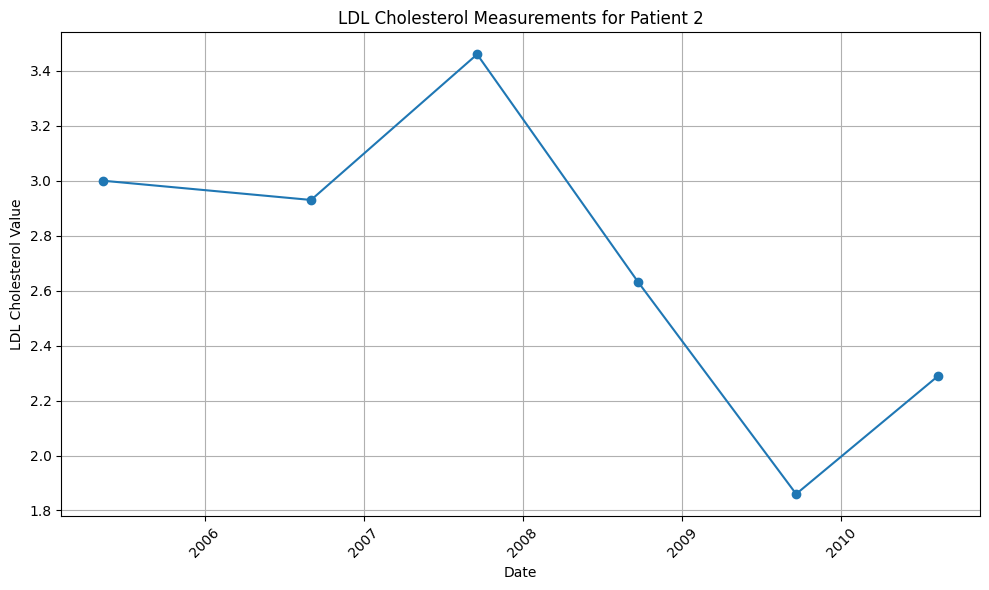

In [7]:
patient_id = patients_df['id'].iloc[0]

observation_url = BASE_URL + f'Observation?patient={patient_id}&code={cholesterol_code}'
obs_response = requests.get(observation_url)

obs_data = json.loads(obs_response._content)

measurements = []
for entry in obs_data.get('entry', []):
    resource = entry.get('resource', {})
    if resource.get('resourceType') == 'Observation':
        date = resource.get('effectiveDateTime')
        value = resource.get('valueQuantity', {}).get('value')
        if date and value:
            measurements.append({'date': date, 'value': float(value)})
measurements_df = pd.DataFrame(measurements)
measurements_df['date'] = pd.to_datetime(measurements_df['date'])
measurements_df = measurements_df.sort_values(by='date')

plt.figure(figsize=(10, 6))
plt.plot(measurements_df['date'], measurements_df['value'], marker='o', linestyle='-')
plt.title(f'LDL Cholesterol Measurements for Patient {patient_id}')
plt.xlabel('Date')
plt.ylabel('LDL Cholesterol Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
print(f"A plot for Patient {patient_id}'s cholesterol has been generated.")
plt.show()